In [2]:
import pandas as pd

df = pd.read_parquet(
    r"C:\Users\lola\github\p04_golez_jackwerth_2024\_data\optionmetrics_spx_monthly.parquet"
)

print("Loaded successfully!")


Loaded successfully!


In [3]:
print(df.columns)
df.head()
df.info()


Index(['date', 'exdate', 'cp_flag', 'strike', 'best_bid', 'best_offer',
       'impl_volatility', 'delta', 'gamma', 'vega', 'volume', 'open_interest',
       'mid_price', 'days_to_maturity', 'year'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 691097 entries, 2192 to 14482952
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              691097 non-null  datetime64[ns]
 1   exdate            691097 non-null  datetime64[ns]
 2   cp_flag           691097 non-null  object        
 3   strike            691097 non-null  float64       
 4   best_bid          691097 non-null  float64       
 5   best_offer        691097 non-null  float64       
 6   impl_volatility   655197 non-null  float64       
 7   delta             655197 non-null  float64       
 8   gamma             655197 non-null  float64       
 9   vega              655197 non-null  float64       
 10  vo

In [4]:
# 重新从 df_day 开始，不要用改过 strike 的版本
df_day = df[df["date"] == df["date"].max()].copy()

# 选 long maturity
df_long = df_day[df_day["days_to_maturity"] > 300]

exdate = df_long["exdate"].value_counts().index[0]
df_tau = df_long[df_long["exdate"] == exdate].copy()

# 自己算 mid
df_tau["mid"] = (df_tau["best_bid"] + df_tau["best_offer"]) / 2

# ⚠️ 不要动 strike
print(df_tau["strike"].head())


14480739    200.0
14480740    400.0
14480741    500.0
14480742    600.0
14480743    800.0
Name: strike, dtype: float64


In [5]:
df_pivot = df_tau.pivot_table(
    index="strike",
    columns="cp_flag",
    values="mid"
).dropna()

print(df_pivot.head())


cp_flag        C     P
strike                
1400.0   4495.75  3.20
1600.0   4305.25  4.35
1800.0   4115.05  5.50
2000.0   3924.55  6.80
2200.0   3735.05  8.20


In [6]:
import pandas as pd
import numpy as np
from itertools import combinations

# 假设 df_tau 已经是你选定的一天、满足 days_to_maturity > 90 的 DataFrame
# 并且已经 pivot 成 df_pivot
# df_pivot = df_tau.pivot_table(index="strike", columns="cp_flag", values="mid_price").dropna()

# -------------------------------
# Step 1: 基础信息
# -------------------------------
strikes = df_pivot.index.values
tau = df_tau["days_to_maturity"].iloc[0] / 365  # 剩余年数

print("Tau (years):", tau)
print("Total strikes:", len(strikes))
print("Columns in pivot:", df_pivot.columns)
print("Sample strikes:", strikes[:10])
print("Sample prices:\n", df_pivot.head())

# -------------------------------
# Step 2: 遍历组合并计算 numerator / denominator
# -------------------------------
rates = []
ratios = []
total_combinations = 0

for Xj, Xi in combinations(strikes, 2):  # 注意顺序
    Pi = df_pivot.loc[Xi, "P"]
    Ci = df_pivot.loc[Xi, "C"]
    Pj = df_pivot.loc[Xj, "P"]
    Cj = df_pivot.loc[Xj, "C"]

    numerator = (Pi - Ci) - (Pj - Cj)
    denominator = Xi - Xj  # 正数，因为 Xi > Xj

    total_combinations += 1
    ratios.append(numerator / denominator)

    # 打印前 5 个 debug 信息
    if total_combinations <= 5:
        print(f"Xi={Xi}, Xj={Xj}, numerator={numerator:.2f}, denominator={denominator:.2f}, ratio={numerator/denominator:.4f}")

    # 只保留 numerator / denominator > 0 的情况
    if numerator / denominator > 0:
        r = - (1 / tau) * np.log(numerator / denominator)
        rates.append(r)

# -------------------------------
# Step 3: 输出 debug 统计
# -------------------------------
print("\nTotal combinations:", total_combinations)
print("Number of valid rates:", len(rates))
if len(ratios) > 0:
    print("Ratio stats: min={:.4f}, max={:.4f}, median={:.4f}".format(
        np.min(ratios), np.max(ratios), np.median(ratios)))
else:
    print("No ratios computed. Check pivot or filtering.")

# -------------------------------
# Step 4: 计算中位数 implied rate
# -------------------------------
if rates:
    r_implied = np.median(rates)
    print("Implied rate =", r_implied)
    print("In % =", r_implied * 100)
else:
    print("No valid implied rates computed. Check numerator/denominator logic or data filtering.")



Tau (years): 0.9671232876712329
Total strikes: 166
Columns in pivot: Index(['C', 'P'], dtype='object', name='cp_flag')
Sample strikes: [1400. 1600. 1800. 2000. 2200. 2400. 2500. 2600. 2700. 2800.]
Sample prices:
 cp_flag        C     P
strike                
1400.0   4495.75  3.20
1600.0   4305.25  4.35
1800.0   4115.05  5.50
2000.0   3924.55  6.80
2200.0   3735.05  8.20
Xi=1600.0, Xj=1400.0, numerator=191.65, denominator=200.00, ratio=0.9583
Xi=1800.0, Xj=1400.0, numerator=383.00, denominator=400.00, ratio=0.9575
Xi=2000.0, Xj=1400.0, numerator=574.80, denominator=600.00, ratio=0.9580
Xi=2200.0, Xj=1400.0, numerator=765.70, denominator=800.00, ratio=0.9571
Xi=2400.0, Xj=1400.0, numerator=957.15, denominator=1000.00, ratio=0.9572

Total combinations: 13695
Number of valid rates: 13695
Ratio stats: min=0.9220, max=1.0240, median=0.9573
Implied rate = 0.04511722118284044
In % = 4.511722118284045


In [10]:
print("Sample pivot table for date 1996-01-31, maturity 1996-06-22:")
print(df_pivot.head())
print("Pivot shape:", df_pivot.shape)


Sample pivot table for date 1996-01-31, maturity 1996-06-22:
cp_flag       C      P
strike                
800.0    5023.1   5.35
1200.0   4707.9   9.45
1600.0   4394.7  16.40
1800.0   4239.6  20.30
2000.0   4085.4  27.40
Pivot shape: (65, 2)


In [13]:
import pandas as pd
import numpy as np
from itertools import combinations
from sklearn.linear_model import LinearRegression

def calc_outer_product_rate(df_pivot, tau):
    """Outer Product Approach (1996-2003)"""
    strikes = sorted(df_pivot.index.values)
    rates = []
    # Xi > Xj 的组合
    for Xj, Xi in combinations(strikes, 2):
        val_i = df_pivot.loc[Xi, 'P'] - df_pivot.loc[Xi, 'C']
        val_j = df_pivot.loc[Xj, 'P'] - df_pivot.loc[Xj, 'C']
        
        numerator = val_i - val_j
        denominator = Xi - Xj
        
        ratio = numerator / denominator
        if ratio > 0:
            r = -(1/tau) * np.log(ratio)
            rates.append(r)
    return np.median(rates) if rates else np.nan

def calc_regression_rate(df_pivot, tau, S):
    """Regression Approach (2004-2022)
    Model: S - C + P = P_div + beta * X + epsilon
    r = -1/tau * ln(beta)
    """
    # 准备数据: y = S - C + P, x = X
    df_reg = df_pivot.copy()
    df_reg['y'] = S - df_reg['C'] + df_reg['P']
    X = df_reg.index.values.reshape(-1, 1)
    y = df_reg['y'].values
    
    model = LinearRegression().fit(X, y)
    beta = model.coef_[0]
    
    if beta > 0:
        return -(1/tau) * np.log(beta)
    return np.nan

In [15]:
import pandas as pd
import numpy as np
from itertools import combinations
from sklearn.linear_model import LinearRegression
from tqdm import tqdm

# 1. 加载数据
df = pd.read_parquet(r"C:\Users\lola\github\p04_golez_jackwerth_2024\_data\optionmetrics_spx_monthly.parquet")

# 2. 预处理与初步过滤
df['mid'] = (df['best_bid'] + df['best_offer']) / 2
df['date'] = pd.to_datetime(df['date'])
df['exdate'] = pd.to_datetime(df['exdate'])
df['tau'] = (df['exdate'] - df['date']).dt.days / 365

# 论文过滤条件：价格 > $3，期限 >= 90天
df = df[(df['mid'] > 3) & (df['days_to_maturity'] >= 90)].copy()

# 3. 定义计算函数
def get_rate_for_group(group):
    # group 内部是同一个 date 和同一个 exdate 的所有 strike
    dt = group['date'].iloc[0]
    tau = group['tau'].iloc[0]
    
    # 转换成 P-C 矩阵
    # 确保同时有 Call 和 Put 对应的 strike 才会保留
    pivot = group.pivot_table(index="strike", columns="cp_flag", values="mid").dropna()
    
    if len(pivot) < 2: 
        return None

    try:
        if dt.year <= 2003:
            # --- Outer Product Approach ---
            strikes = sorted(pivot.index.values)
            ratios = []
            # 使用 combinations 获取所有 Xi > Xj 的组合
            for Xj, Xi in combinations(strikes, 2):
                # (Pi - Ci) - (Pj - Cj)
                num = (pivot.loc[Xi, 'P'] - pivot.loc[Xi, 'C']) - (pivot.loc[Xj, 'P'] - pivot.loc[Xj, 'C'])
                den = Xi - Xj
                ratio = num / den
                if ratio > 0:
                    ratios.append(ratio)
            
            if not ratios: return None
            # 取比例的中位数后转为连续复利利率
            r_implied = -(1/tau) * np.log(np.median(ratios))
            
        else:
            # --- Regression Approach ---
            # St - C + P = P_div + beta*X  =>  P - C = (P_div - St) + beta*X
            # 我们只需要斜率 beta = exp(-r*tau)
            y = (pivot['P'] - pivot['C']).values
            X = pivot.index.values.reshape(-1, 1)
            
            model = LinearRegression().fit(X, y)
            beta = model.coef_[0]
            
            if beta <= 0: return None
            r_implied = -(1/tau) * np.log(beta)
            
        return r_implied
    except:
        return None

# 4. 执行分组计算
tqdm.pandas(desc="Calculating Implied Rates")
# 按日期和到期日分组
results = df.groupby(['date', 'exdate']).progress_apply(get_rate_for_group)

# 5. 整理结果
df_res = results.reset_index()
df_res.columns = ['date', 'exdate', 'r_implied']

# 重新计算 tau 用于插值或后续分析
df_res['tau'] = (df_res['exdate'] - df_res['date']).dt.days / 365.0
df_res = df_res.dropna(subset=['r_implied'])

# 6. (可选) 过滤掉由于数据噪音产生的极端利率 (例如 > 20% 或 < -10%)
df_res = df_res[(df_res['r_implied'] < 0.2) & (df_res['r_implied'] > -0.1)]

print("\n--- 结果样本 ---")
print(df_res.head())


Calculating Implied Rates: 100%|██████████| 3633/3633 [00:13<00:00, 260.57it/s]


--- 结果样本 ---
        date     exdate  r_implied       tau
0 1996-01-31 1996-06-22   0.057361  0.391781
1 1996-01-31 1996-09-21   0.053781  0.641096
2 1996-01-31 1996-12-21   0.053673  0.890411
3 1996-01-31 1997-06-21   0.055793  1.389041
4 1996-01-31 1997-12-20   0.055815  1.887671


In [16]:
# 定义保存路径
save_path = r"C:\Users\lola\github\p04_golez_jackwerth_2024\_data\option_implied_rates_1996_2022.parquet"

# 保存为 Parquet
df_res.to_parquet(save_path)

# 如果你还想存一个 CSV 版本方便查看
save_path_csv = r"C:\Users\lola\github\p04_golez_jackwerth_2024\_data\option_implied_rates_1996_2022.csv"
df_res.to_csv(save_path_csv, index=False)

print(f"文件已保存至: {save_path}")

文件已保存至: C:\Users\lola\github\p04_golez_jackwerth_2024\_data\option_implied_rates_1996_2022.parquet


In [1]:
import pandas as pd

df = pd.read_parquet(
    r"C:\Users\lola\github\p04_golez_jackwerth_2024\_data\option_implied_rates_1996_2022.parquet"
)

df.head()


,date,exdate,r_implied,tau
0,1996-01-31,1996-06-22,0.057361,0.391781
1,1996-01-31,1996-09-21,0.053781,0.641096
2,1996-01-31,1996-12-21,0.053673,0.890411
3,1996-01-31,1997-06-21,0.055793,1.389041
4,1996-01-31,1997-12-20,0.055815,1.887671


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet(r"C:\Users\lola\github\p04_golez_jackwerth_2024\_data\option_implied_rates_1996_2022.parquet")

df["date"] = pd.to_datetime(df["date"])

# 对每个date，选tau最接近1年的那一条
df_1y = (
    df.loc[df.groupby("date")["tau"].apply(lambda x: (x - 1).abs().idxmin())]
    .reset_index(drop=True)
)

df_1y.head()


,date,exdate,r_implied,tau
0,1996-01-31,1996-12-21,0.053673,0.890411
1,1996-02-29,1996-12-21,0.071934,0.810959
2,1996-03-29,1997-03-22,0.053639,0.980822
3,1996-04-30,1997-03-22,0.058904,0.893151
4,1996-05-31,1997-06-21,0.061027,1.057534


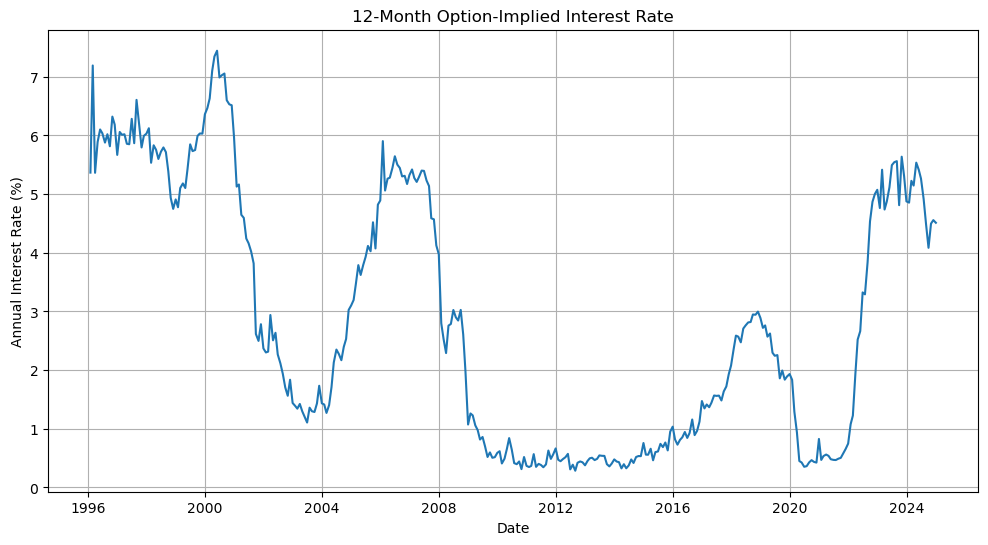

In [5]:
plt.figure(figsize=(12,6))
plt.plot(df_1y["date"], df_1y["r_implied"] * 100)

plt.title("12-Month Option-Implied Interest Rate")
plt.ylabel("Annual Interest Rate (%)")
plt.xlabel("Date")
plt.grid(True)
plt.show()


C:\Users\lola\AppData\Local\Temp\ipykernel_18668\1534041377.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_interp = df.groupby("date").apply(interpolate_1y).dropna().reset_index()


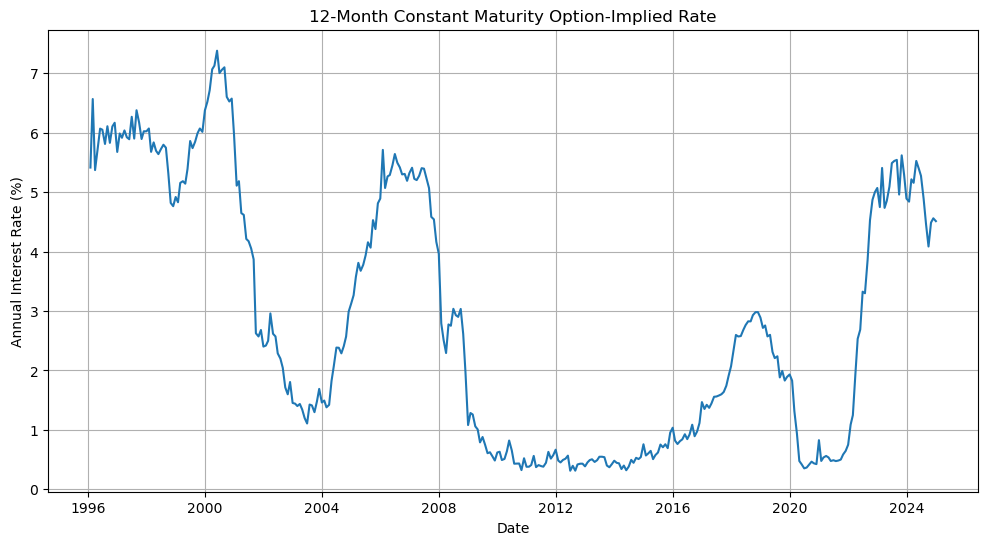

In [6]:
def interpolate_1y(group):
    group = group.sort_values("tau")
    
    below = group[group["tau"] <= 1].tail(1)
    above = group[group["tau"] > 1].head(1)
    
    if len(below) == 1 and len(above) == 1:
        t1, r1 = below["tau"].values[0], below["r_implied"].values[0]
        t2, r2 = above["tau"].values[0], above["r_implied"].values[0]
        
        # 线性插值
        r_interp = r1 + (r2 - r1) * (1 - t1) / (t2 - t1)
        return pd.Series({"r_1y": r_interp})
    else:
        return pd.Series({"r_1y": np.nan})

df_interp = df.groupby("date").apply(interpolate_1y).dropna().reset_index()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  

plt.figure(figsize=(12,6))
plt.plot(df_interp["date"], df_interp["r_1y"] * 100)

plt.title("12-Month Constant Maturity Option-Implied Rate")
plt.xlabel("Date")
plt.ylabel("Annual Interest Rate (%)")
plt.grid(True)

plt.show()



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# implied rate
df_imp = pd.read_parquet(
    r"C:\Users\lola\github\p04_golez_jackwerth_2024\_data\option_implied_rates_1996_2022.parquet"
)

# zero curve
df_zero = pd.read_parquet(
    r"C:\Users\lola\github\p04_golez_jackwerth_2024\_data\optionmetrics_zero_curve.parquet"
)

# treasury
df_treas = pd.read_parquet(
    r"C:\Users\lola\github\p04_golez_jackwerth_2024\_data\fred_treasury_rates.parquet"
)


In [9]:
def interpolate_1y(group):
    group = group.sort_values("tau")

    below = group[group["tau"] <= 1]
    above = group[group["tau"] >= 1]

    if len(below) == 0 or len(above) == 0:
        return pd.Series({"r_1y": np.nan})

    r1 = below.iloc[-1]
    r2 = above.iloc[0]

    if r1["tau"] == r2["tau"]:
        return pd.Series({"r_1y": r1["r_implied"]})

    weight = (1 - r1["tau"]) / (r2["tau"] - r1["tau"])
    r_interp = r1["r_implied"] + weight * (r2["r_implied"] - r1["r_implied"])

    return pd.Series({"r_1y": r_interp})

df_imp_1y = (
    df_imp.groupby("date")
    .apply(interpolate_1y)
    .dropna()
    .reset_index()
)


C:\Users\lola\AppData\Local\Temp\ipykernel_18668\1050739485.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_1y)


In [10]:
df_zero.columns


Index(['date', 'days', 'rate'], dtype='object')

In [11]:
df_zero["tau"] = df_zero["days"] / 365


In [12]:
def interpolate_zero_1y(group):
    group = group.sort_values("tau")

    below = group[group["tau"] <= 1]
    above = group[group["tau"] >= 1]

    if len(below) == 0 or len(above) == 0:
        return pd.Series({"zero_1y": np.nan})

    r1 = below.iloc[-1]
    r2 = above.iloc[0]

    if r1["tau"] == r2["tau"]:
        return pd.Series({"zero_1y": r1["rate"]})

    weight = (1 - r1["tau"]) / (r2["tau"] - r1["tau"])
    r_interp = r1["rate"] + weight * (r2["rate"] - r1["rate"])

    return pd.Series({"zero_1y": r_interp})

df_zero_1y = (
    df_zero.groupby("date")
    .apply(interpolate_zero_1y)
    .dropna()
    .reset_index()
)


C:\Users\lola\AppData\Local\Temp\ipykernel_18668\2833729296.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_zero_1y)


In [13]:
df_zero_1y.head()


,date,zero_1y
0,1996-01-02,5.272127
1,1996-01-03,5.261243
2,1996-01-04,5.259582
3,1996-01-05,5.267515
4,1996-01-08,5.271106


In [15]:
df_imp_1y.head()
df_zero_1y.head()
df_treas.head()


,date,rf_1m,treasury_2y,treasury_10y
0,1962-01-02,NaN,NaN,0.0406
1,1962-01-03,NaN,NaN,0.0403
2,1962-01-04,NaN,NaN,0.0399
3,1962-01-05,NaN,NaN,0.0402
4,1962-01-08,NaN,NaN,0.0403


In [16]:
df_treas.columns


Index(['date', 'rf_1m', 'treasury_2y', 'treasury_10y'], dtype='object')

In [17]:
df_treas["treasury_1y"] = df_treas["treasury_2y"]


In [18]:
df_treas = df_treas[
    (df_treas["date"] >= "1996-01-01") &
    (df_treas["date"] <= "2022-12-31")
]


In [19]:
df_all = df_imp_1y.merge(df_zero_1y, on="date", how="inner")
df_all = df_all.merge(df_treas[["date", "treasury_1y"]], on="date", how="inner")

df_all = df_all.sort_values("date")


In [20]:
df_all.head()


,date,r_1y,zero_1y,treasury_1y
0,1996-01-31,0.054139,4.991435,0.0493
1,1996-02-29,0.065671,5.320260,0.0544
2,1996-03-29,0.053715,5.589250,0.0579
3,1996-04-30,0.057203,5.808064,0.0603
4,1996-05-31,0.060690,5.994259,0.0627


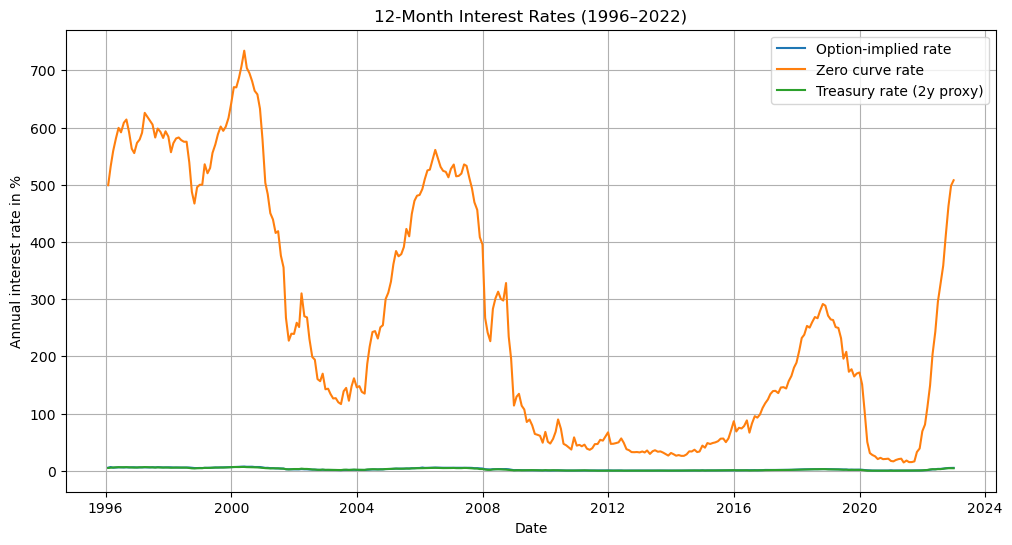

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df_all["date"], df_all["r_1y"] * 100, label="Option-implied rate")
plt.plot(df_all["date"], df_all["zero_1y"] * 100, label="Zero curve rate")
plt.plot(df_all["date"], df_all["treasury_1y"] * 100, label="Treasury rate (2y proxy)")

plt.ylabel("Annual interest rate in %")
plt.xlabel("Date")
plt.legend()
plt.grid(True)

plt.title("12-Month Interest Rates (1996–2022)")
plt.show()


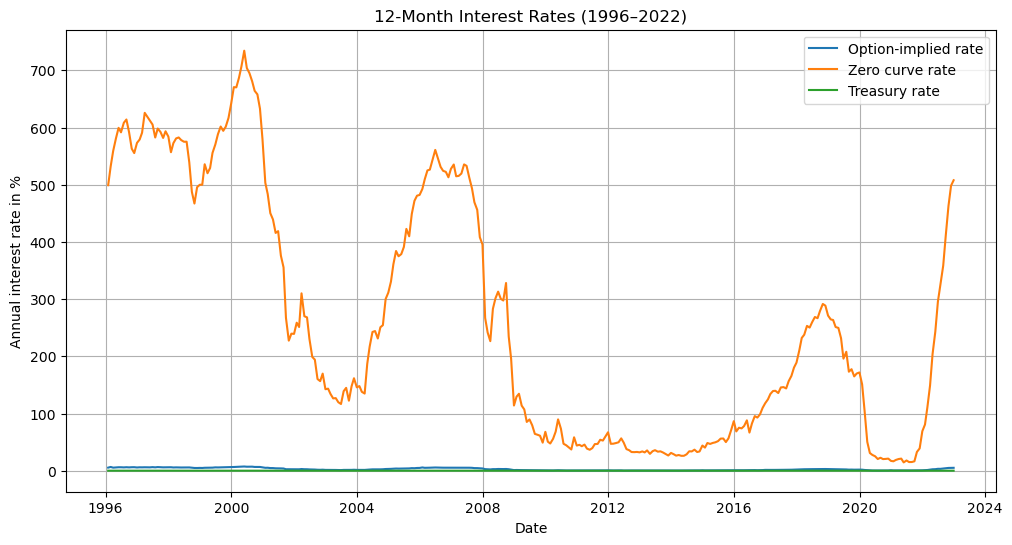

In [23]:
plt.figure(figsize=(12,6))

plt.plot(df_all["date"], df_all["r_1y"] * 100, label="Option-implied rate")
plt.plot(df_all["date"], df_all["zero_1y"] * 100, label="Zero curve rate")
plt.plot(df_all["date"], df_all["treasury_1y"], label="Treasury rate")

plt.ylabel("Annual interest rate in %")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.title("12-Month Interest Rates (1996–2022)")
plt.show()


In [24]:
df_zero["rate"].describe()


count    302486.000000
mean          3.280783
std           2.107220
min           0.058684
25%           1.469498
50%           2.905240
75%           5.184873
max           7.981904
Name: rate, dtype: float64

In [25]:
df_zero.head()


,date,days,rate,tau
0,1996-01-02,9.0,5.763067,0.024658
1,1996-01-02,15.0,5.745902,0.041096
2,1996-01-02,50.0,5.673317,0.136986
3,1996-01-02,78.0,5.608884,0.213699
4,1996-01-02,169.0,5.473762,0.463014


In [27]:
df_all[["r_1y", "zero_1y", "treasury_1y"]].describe()



,r_1y,zero_1y,treasury_1y
count,324.000000,324.000000,324.000000
mean,0.026825,2.598547,0.025190
std,0.021416,2.156405,0.020418
min,0.003127,0.145554,0.001100
25%,0.006282,0.554311,0.006625
50%,0.020566,1.949150,0.019200
75%,0.048990,4.888592,0.044100
max,0.073799,7.342412,0.066900


In [28]:
df_all["zero_1y"] = df_all["zero_1y"] / 100


In [29]:
df_all[["r_1y", "zero_1y", "treasury_1y"]].describe()


,r_1y,zero_1y,treasury_1y
count,324.000000,324.000000,324.000000
mean,0.026825,0.025985,0.025190
std,0.021416,0.021564,0.020418
min,0.003127,0.001456,0.001100
25%,0.006282,0.005543,0.006625
50%,0.020566,0.019491,0.019200
75%,0.048990,0.048886,0.044100
max,0.073799,0.073424,0.066900


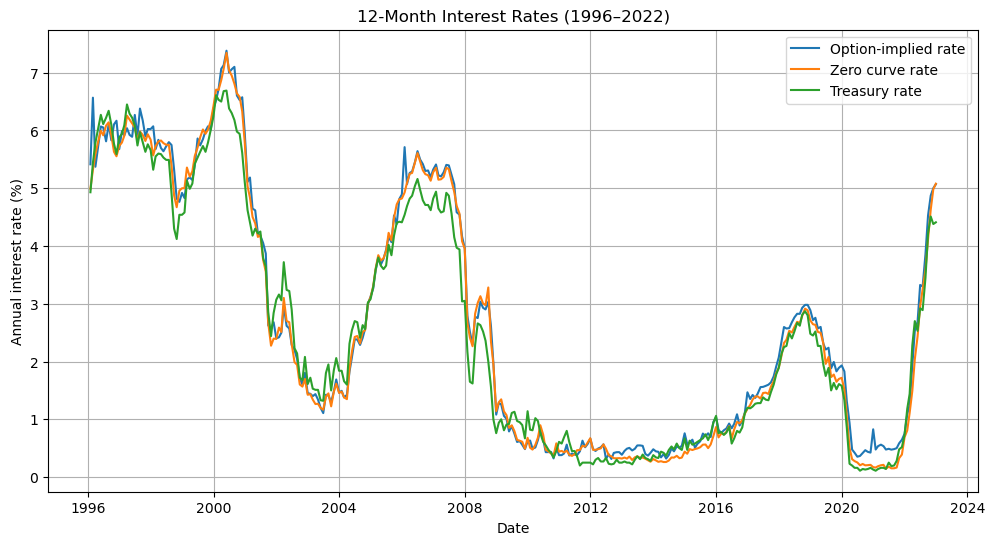

In [30]:
plt.figure(figsize=(12,6))

plt.plot(df_all["date"], df_all["r_1y"] * 100, label="Option-implied rate")
plt.plot(df_all["date"], df_all["zero_1y"] * 100, label="Zero curve rate")
plt.plot(df_all["date"], df_all["treasury_1y"] * 100, label="Treasury rate")

plt.ylabel("Annual interest rate (%)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.title("12-Month Interest Rates (1996–2022)")
plt.show()


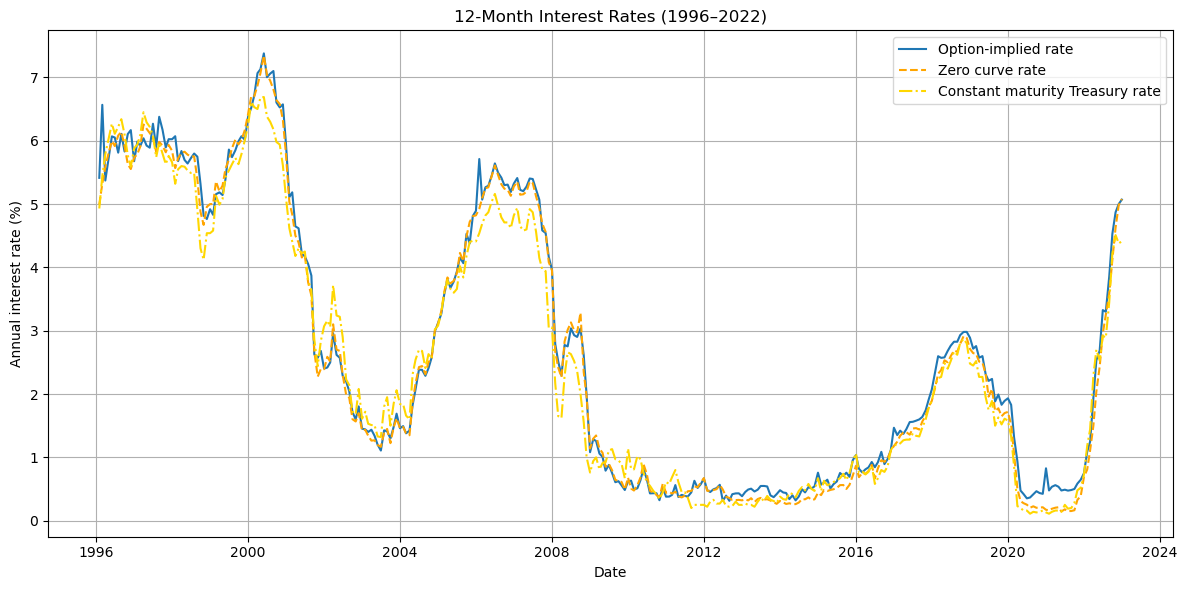

In [31]:
plt.figure(figsize=(12,6))

# Option-implied rate（默认蓝色实线）
plt.plot(
    df_all["date"],
    df_all["r_1y"] * 100,
    label="Option-implied rate"
)

# Zero curve rate（橙色虚线）
plt.plot(
    df_all["date"],
    df_all["zero_1y"] * 100,
    linestyle="--",
    color="orange",
    label="Zero curve rate"
)

# Treasury rate（黄色 点+线）
plt.plot(
    df_all["date"],
    df_all["treasury_1y"] * 100,
    linestyle="-.",
    color="gold",
    label="Constant maturity Treasury rate"
)

plt.ylabel("Annual interest rate (%)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.title("12-Month Interest Rates (1996–2022)")

plt.tight_layout()
plt.show()
